In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("../data/processed/cleaned_baywheels_df.csv")
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,start_hour,start_day,start_month,route_id
0,28929E5AFD15A2FB,electric_bike,2024-12-02 17:51:35.798,2024-12-02 17:54:29.841,O'Farrell St at Masonic Ave,SF-H16,Page St at Masonic Ave,SF-K16,37.781131,-122.447374,37.771135,-122.445341,member,17,Monday,12,SF-H16-SF-K16
1,5FC879CAC379C364,electric_bike,2024-12-30 12:01:54.081,2024-12-30 12:34:35.126,Greenwich St at Franklin St,SF-B21,Mason St at Halleck St,SF-A15,37.800287,-122.425786,37.803968,-122.455079,casual,12,Monday,12,SF-B21-SF-A15
2,7BF609D17E4AE925,electric_bike,2024-12-24 07:59:08.908,2024-12-24 08:01:14.056,San Francisco Public Library,SF-I24,Grove St at Gough St,SF-J22-2,37.778799,-122.415963,37.777870,-122.422953,member,7,Tuesday,12,SF-I24-SF-J22-2
3,9DEA637C58FBDDBA,electric_bike,2024-12-29 15:19:35.704,2024-12-29 15:26:32.882,Market St at Franklin St,SF-K22-1,Church St at Duboce Ave,SF-L20,37.773793,-122.421239,37.769818,-122.429148,member,15,Sunday,12,SF-K22-1-SF-L20
4,BD56E9D0CDA65000,classic_bike,2024-12-21 16:44:18.909,2024-12-21 16:46:07.511,Parker St at Fulton St,BK-F8,Parker St at Fulton St,BK-F8,37.862464,-122.264791,37.862464,-122.264791,member,16,Saturday,12,BK-F8-BK-F8


### Identifying Sinks and Sources
Look at the stations with critical capacity.

I look into the Cumulative Net Flow to see if and when a station hits a critical capacity (Empty or Full).

In [10]:
df["end_hour"] = pd.to_datetime(df["ended_at"]).dt.hour

In [11]:
ins_df = df.groupby(["start_station_name", "start_hour"])["ride_id"].count().reset_index()

outs_df = df.groupby(["end_station_name", "end_hour"])["ride_id"].count().reset_index()

ins_df = ins_df.rename(columns={"start_station_name": "station", "ride_id": "arrivals", "start_hour": "hour"})
outs_df = outs_df.rename(columns={"end_station_name": "station", "ride_id": "departures", "end_hour": "hour"})

flow_df = pd.merge(outs_df, ins_df, on=["station", "hour"], how="outer")

flow_df["net_flow"] = flow_df["arrivals"] - flow_df["departures"]

Firstly, I try to identify Sinks and Sources, to do that I look at the magnitude of net_flow, if:
- sources: a negative net flow means bikes are "venting" out of the station. Not refilled -> zero
- sinks: a positive net flow means bikes are "draining" into the station. Not emptied -> overflow

I look into the most imbalanced stations across the entire day. This helps me to identify "problem stations" for the operations team.

In [12]:
global_flow = flow_df.groupby("station")["net_flow"].sum().reset_index()

# Top 5 Sources
sources = global_flow.sort_values(by="net_flow").head(5)

# Top 5 Sinks
sinks = global_flow.sort_values(by="net_flow", ascending=False).head(5)

print("Top 5 Stations that needs constant refills:")
sources

Top 5 Stations that needs constant refills:


,station,net_flow
515,Salesforce Transit Center,-2965.0
524,San Francisco Caltrain Station - Townsend St,-2424.0
420,Mechanics Monument Plaza,-2395.0
350,JFK Dr at Great Highway,-2247.0
9,11th St at Bryant St,-2160.0


In [13]:
print("Top 5 Stations that needs constant emptying:")
sinks

Top 5 Stations that needs constant emptying:


,station,net_flow
318,Haight St at Lyon St,4347.0
393,Lyon St at Fell St,3903.0
462,Page St at Masonic Ave,3413.0
369,Koshland Park,3358.0
371,Lafayette Park,3327.0


Visualize top 5 Sinks and Sources across the day.

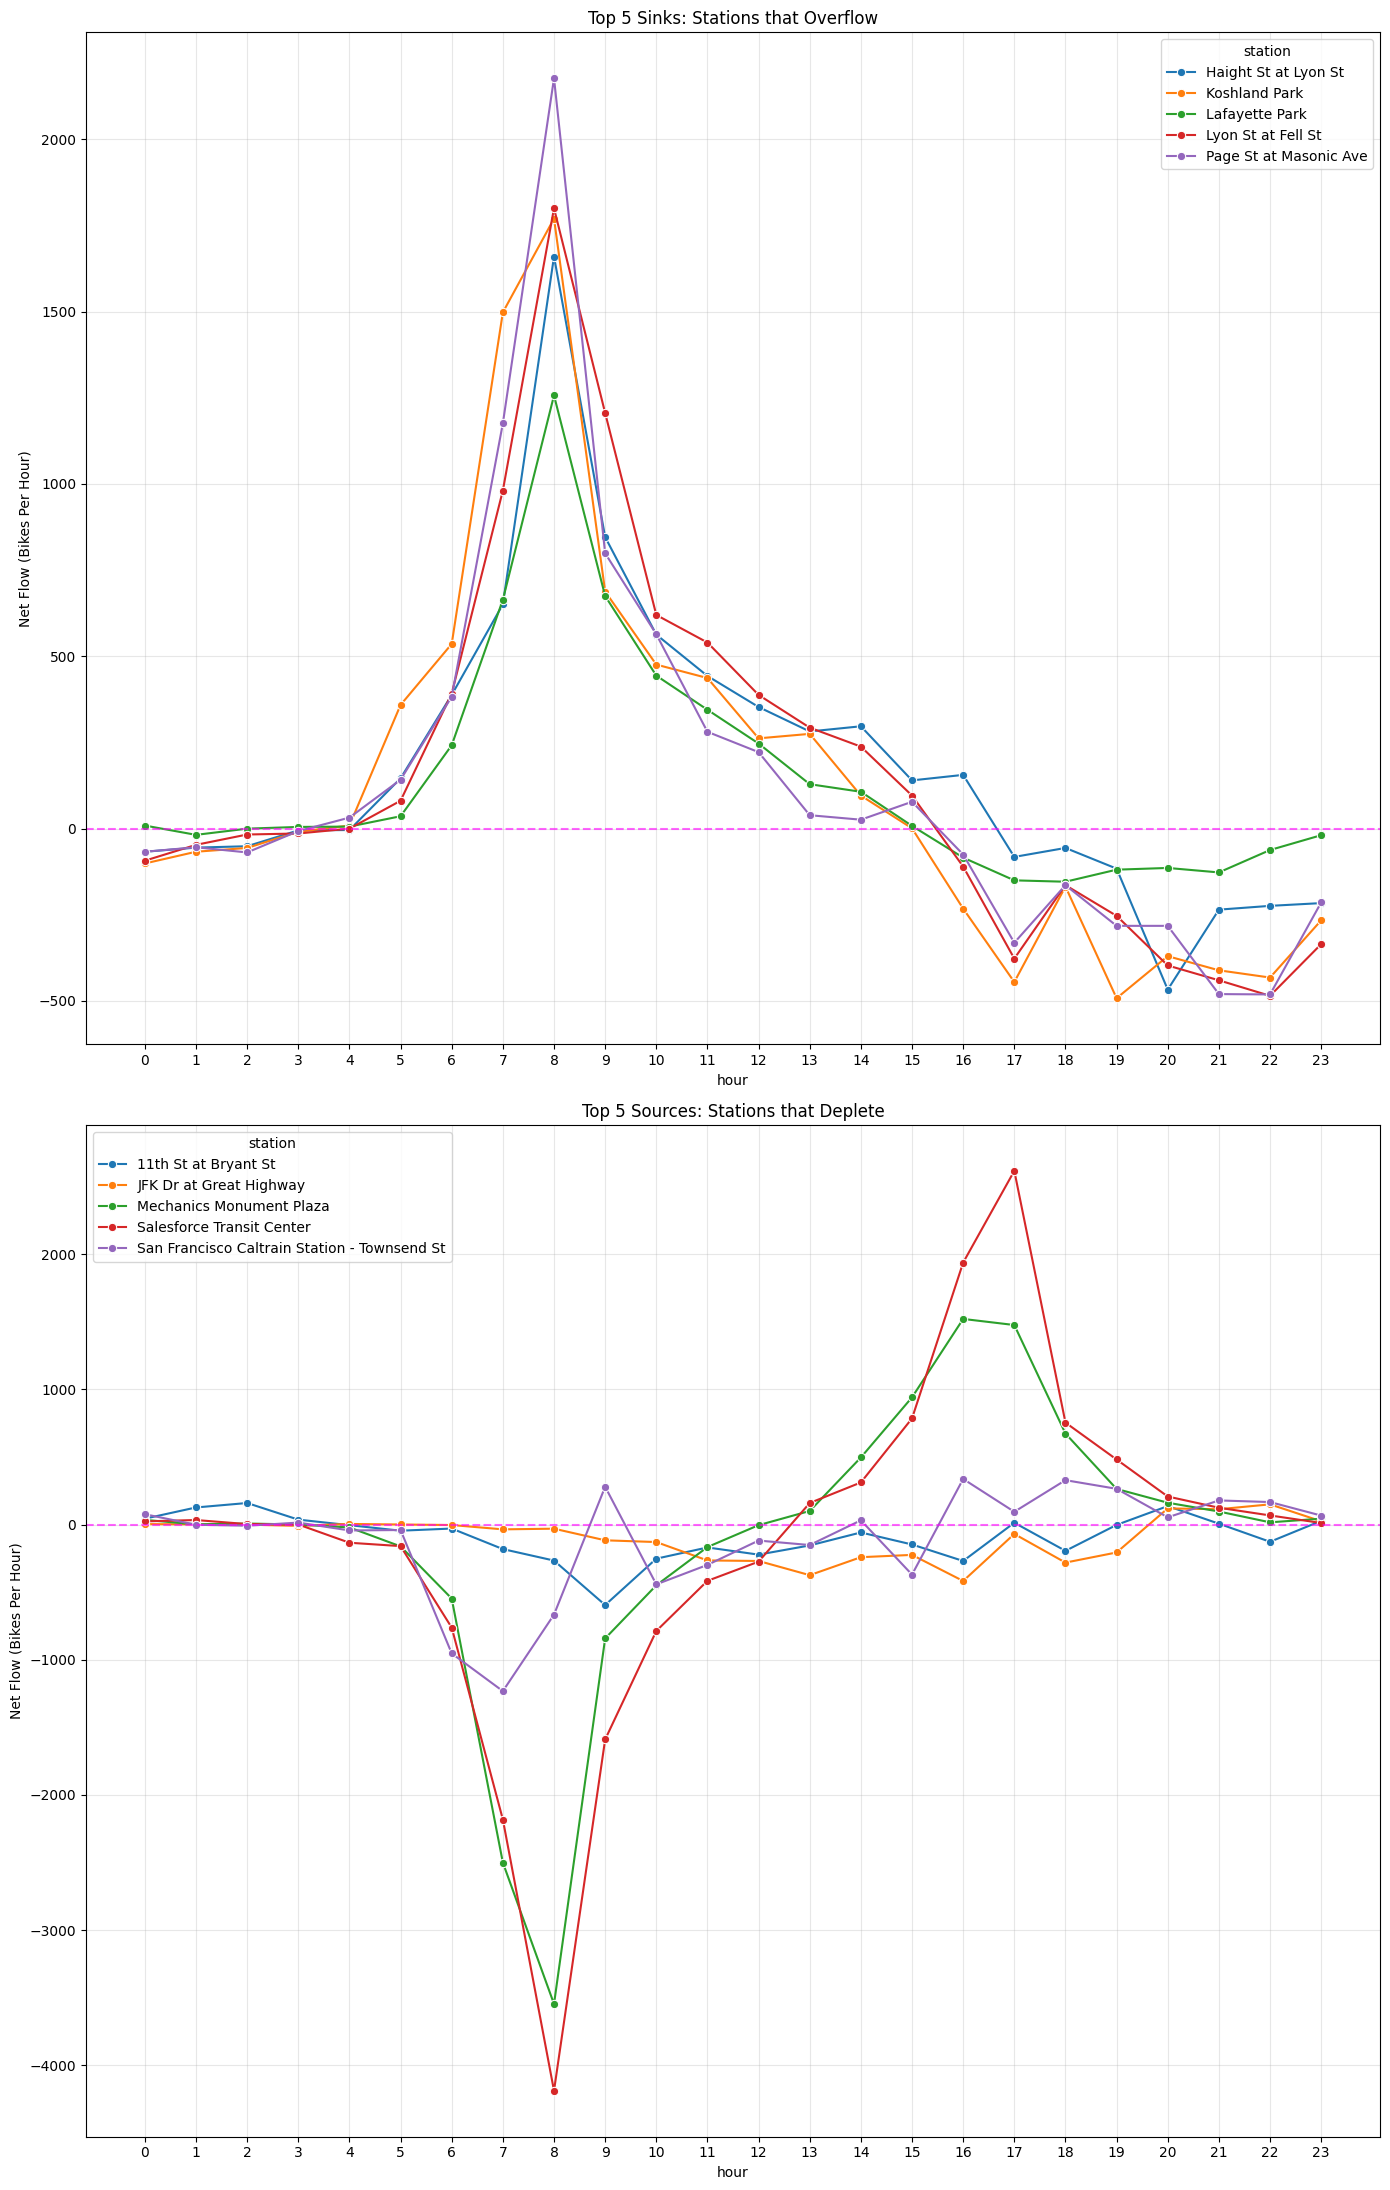

In [14]:
viz_flow = flow_df.groupby("station")["net_flow"].sum()

top_sinks = viz_flow.nlargest(5).index.tolist()
top_sources = viz_flow.nsmallest(5).index.tolist()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 22))

# Top 5 sinks
sink_data = flow_df[flow_df["station"].isin(top_sinks)]
sns.lineplot(data=sink_data, x="hour", y="net_flow", hue="station", marker="o", ax=ax1)
ax1.axhline(0, color="magenta", linestyle="--", alpha=0.6)
ax1.set_xticks(range(0,24))
ax1.set_title("Top 5 Sinks: Stations that Overflow")
ax1.set_ylabel("Net Flow (Bikes Per Hour)")
ax1.grid(alpha=0.3)

# Top 5 sources
source_data = flow_df[flow_df["station"].isin(top_sources)]
sns.lineplot(data=source_data, x="hour", y="net_flow", hue="station", marker="o", ax=ax2)
ax2.axhline(0, color="magenta", linestyle="--", alpha=0.6)
ax2.set_xticks(range(0,24))
ax2.set_title("Top 5 Sources: Stations that Deplete")
ax2.set_ylabel("Net Flow (Bikes Per Hour)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Insights:**

- The data shows a clear behavioral gap. While thousand of riders grab bikes from Transit Hubs (Sources) in the morning to get to work on time, a much smaller percentage uses them to return in the evening. It means transit hubs end the day in a "bike debt" that only manual rebalancing can fix.

- I observed massive "inflow" spikes at residential and park stations (Sinks) during the morning. These spikes are likely "artificial". Vans bring bikes into residential area at 4AM so users can deplete the by 9AM. Without this intervention, the morning commute would collapse.

**Conclusions:**

- Prioritizing maintenance at stations that don't return to 0 naturally.
- By targeting "one-way" hubs identified in the graph, van fuel costs can be reduced by timing drop-offs exactly 30 minutes before the morning Depleting begins.

### Asset Usage
Deciding how to use maintenance budget.

*Question:* For wach bike type, what % are Casual vs. Member?

In [15]:
asset_usage = df.groupby(["rideable_type", "member_casual"]).size().unstack(fill_value=0)
asset_usage_pct = asset_usage.div(asset_usage.sum(axis=1), axis=0) * 100
asset_usage_pct

member_casual,casual,member
rideable_type,,
classic_bike,22.333081,77.666919
electric_bike,21.302293,78.697707


Since 79% of all rides are Electric, there must be a higher need in vans to swap batteries. Casual bikes can serve as "Insurance Policy" as they don't need charging and even if the van is late commuters can still get to their destinations.